# 236 - Does the decomposition hold up?

**Figure F7.** Every stability number here is printed next to a **size-matched null**. That is not decoration: on this cohort a leave-one-patient-out minimum of 0.448 looked like patient fragility until random groups of the same sizes scored 0.459 +/- 0.019.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, "functions")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import lf_decompose as D

RUN = Path("outputs/clustering/kmeans/concat_hg/runs/20260803_175417")
OUT = Path("outputs/clustering/decomposition"); OUT.mkdir(parents=True, exist_ok=True)

X    = np.load(RUN / "X_train.npy").astype(np.float64)
lab  = pd.read_csv(RUN / "labels.csv")
CCOL = next(c for c in lab.columns if c.startswith("cluster_") and not c.endswith("_ranked"))
y5   = lab[CCOL].to_numpy()
pat  = lab["patient_id"].astype(str).to_numpy()

# fsaverage coordinates, for anatomical coherence
_co = pd.read_csv("outputs/250_recon/fsaverage/coords/ALL_PATIENTS_contacts_fsaverage.csv")
_nz = lambda s: str(s).replace("_", "").replace("-", "").upper()
_co["key"] = [f"{p}|{_nz(x)}" for p, x in zip(_co["patient"], _co["name"])]
lab["key"] = [f"{p}|{_nz(e)}" for p, e in zip(lab["patient_id"], lab["electrode"])]
XYZ = lab.merge(_co[["key", "x", "y", "z"]], on="key", how="left")[["x", "y", "z"]].to_numpy()

CONDS = ["audio", "picture", "reading"]; NT = X.shape[1] // 3
print(f"{X.shape[0]} electrodes x {X.shape[1]} features | {len(np.unique(pat))} patients "
      f"| {np.isnan(XYZ).any(1).sum()} without coordinates")

1027 electrodes x 900 features | 24 patients | 0 without coordinates


## 1 - Leave-one-patient-out, against a pseudo-patient null

In [2]:
Xs = D.unit_norm(X); K = 7
real = D.lopo_stability(Xs, pat, K)
null = D.pseudo_group_null(Xs, pat, K, n_rep=6)
ok_ = ~real["degenerate"]
print(f"real (all folds)   mean {real['ari'].mean():.3f}  min {real['ari'].min():.3f}")
print(f"real (clean folds) mean {real.loc[ok_, 'ari'].mean():.3f}  min {real.loc[ok_, 'ari'].min():.3f}"
      f"   [{(~ok_).sum()} degenerate folds dropped]")
print(f"matched null       mean {null['mean'].mean():.3f} +/- {null['mean'].std():.3f}"
      f"  min {null['min'].mean():.3f} +/- {null['min'].std():.3f}")
z = (real.loc[ok_, "ari"].min() - null["min"].mean()) / max(null["min"].std(), 1e-9)
print(f"\n-> observed minimum is z = {z:+.2f} against the matched null "
      f"({'INSIDE it - no patient effect' if abs(z) < 2 else 'outside it'})")
display(real.sort_values("ari").head(8))

real (all folds)   mean 0.903  min 0.643
real (clean folds) mean 0.903  min 0.643   [0 degenerate folds dropped]
matched null       mean 0.923 +/- 0.011  min 0.725 +/- 0.118

-> observed minimum is z = -0.69 against the matched null (INSIDE it - no patient effect)


,group,n,ari,degenerate
23,PAT_6854,147,0.643069,False
1,EL033,65,0.711973,False
15,PAT_3780,47,0.736226,False
22,PAT_6704,41,0.855360,False
12,PAT_3390,13,0.857019,False
13,PAT_3415,18,0.868548,False
5,EL038,48,0.892210,False
0,EL030,77,0.922801,False


## 2 - Consensus across preprocessing pipelines

Rather than defend one pipeline, cluster the **co-association** of many (Lowe & Schall 2018 did this over 48). Pairs that co-cluster only under one choice wash out.

consensus cluster sizes: [  6 245  47 108 127 116 378]
anatomical coherence of the consensus: 0.400 = 1.70x chance


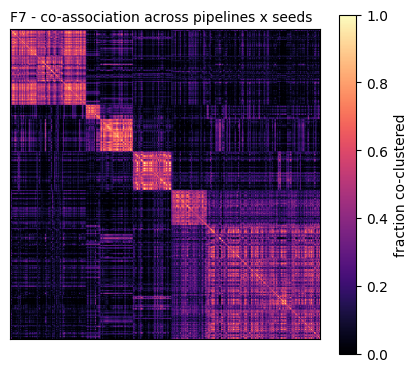

In [3]:
Cass = D.pipeline_consensus(X, K, patient=pat)
ycon = D.consensus_labels(Cass, K)
print("consensus cluster sizes:", np.bincount(ycon))
obs, ratio = D.spatial_coherence(ycon, XYZ)
print(f"anatomical coherence of the consensus: {obs:.3f} = {ratio:.2f}x chance")

fig, ax = plt.subplots(figsize=(5, 4.4))
o = np.argsort(ycon)
im = ax.imshow(Cass[np.ix_(o, o)], cmap="magma", vmin=0, vmax=1)
ax.set_title("F7 - co-association across pipelines x seeds", loc="left", fontsize=10)
ax.set_xticks([]); ax.set_yticks([]); fig.colorbar(im, label="fraction co-clustered")
fig.savefig(OUT / "F7_consensus.png", dpi=150, bbox_inches="tight"); plt.show()

## 3 - Discovery / replication split

Yeo 2011 reported 97.4% of vertices in the same network across independent halves. Ours will be lower - the honest question is how much. Components are matched across halves by profile correlation.

In [4]:
rng = np.random.default_rng(0); ps = np.unique(pat); rows = []
for rep in range(10):
    sh = rng.permutation(ps); A = set(sh[:len(ps) // 2])
    ma = np.isin(pat, list(A))
    _, _, Ca = D.convex_nmf(Xs[ma],  K, random_state=0, n_iter=150)
    _, _, Cb = D.convex_nmf(Xs[~ma], K, random_state=0, n_iter=150)
    M = np.corrcoef(Ca, Cb)[:K, K:]
    rows.append(dict(rep=rep, mean_best_match=float(M.max(1).mean())))
rep_df = pd.DataFrame(rows)
display(rep_df.describe().round(3))
print("mean correlation between best-matching components of independent patient halves:",
      round(rep_df["mean_best_match"].mean(), 3))

,rep,mean_best_match
count,10.000,10.000
mean,4.500,0.687
std,3.028,0.036
min,0.000,0.643
25%,2.250,0.661
50%,4.500,0.676
75%,6.750,0.705
max,9.000,0.746


mean correlation between best-matching components of independent patient halves: 0.687
